In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy import stats
from matplotlib.ticker import FuncFormatter
import statsmodels.api as sm

In [4]:
mut_path = "data/tcga_mut_somaticgermline.tsv"
wt1_path = "data/tcga_WT_drivers.tsv"
wt2_path = "data/tcga_WT_nondrivers.tsv"
roles_path = 'data/generoles.tsv'

In [5]:
mut = pd.read_csv(mut_path, sep = '\t')
wt1 = pd.read_csv(wt1_path, sep = '\t')
wt2 = pd.read_csv(wt2_path, sep = '\t')
roles = pd.read_csv(roles_path, sep = '\t')

/home/sabari/niveditam/miniconda3/envs/equinox_minimal/lib/python3.8/site-packages/IPython/core/interactiveshell.py:3508: DtypeWarning: Columns (12) have mixed types.Specify dtype option on import or set low_memory=False.
  exec(code_obj, self.user_global_ns, self.user_ns)


In [6]:
def config_rcparams():
    plt.rcParams['font.family'] = ['sans-serif']
    plt.rcParams['font.sans-serif'] = ['arial']
    plt.rcParams['svg.fonttype'] = 'none' 
    plt.rcParams['mathtext.fontset'] = 'custom'
    plt.rcParams['mathtext.cal'] = 'arial'
    plt.rcParams['mathtext.rm'] = 'arial'
    plt.rcParams['axes.linewidth'] = 0.7
    plt.rcParams['xtick.major.width'] = 0.7
    plt.rcParams['ytick.major.width'] = 0.7
    plt.rcParams['xtick.major.size'] = 3
    plt.rcParams['ytick.major.size'] = 3

---

# Fig 1B

In [7]:
# preparing dataset 

tcgawt = pd.concat([wt1,wt2])
tcgawt['localCN'] = tcgawt['major']+tcgawt['minor']
tcgamut = mut.copy()

# removing other genes due to much higher number
others = roles[roles.role=='other']['Hugo_Symbol'].unique()

tcgamut = tcgamut[~tcgamut.Hugo_Symbol.isin(others)].copy()
tcgawt = tcgawt[~tcgawt.Hugo_Symbol.isin(others)].copy()

In [8]:
# continued...

tcgawt['localCN'] = tcgawt['major']+tcgawt['minor']

tcgamut['cat'] = ''

mutdel = (tcgamut.zygosity=='2-hit')
onlymut = (tcgamut.zygosity=='1-hit')

tmp = tcgamut.gene_patient.value_counts()
multimut = tmp[tmp>1].index
multimutnodel = np.setdiff1d(multimut,tcgamut[mutdel].gene_patient.unique())
mutmut = (tcgamut.gene_patient.isin(multimutnodel))

mutmut = (tcgamut.gene_patient.isin(multimut)) 

tcgamut['cat'] = tcgamut['cat'].mask(mutdel,'mut+del')
tcgamut['cat'] = tcgamut['cat'].mask(onlymut,'mut')
tcgamut['cat'] = tcgamut['cat'].mask(mutmut,'mut+mut') # note that this is unphased

tcgawt['cat'] = ''

ddel = (tcgawt.zygosity=='2-hit')
wt = (tcgawt.zygosity=='0-hit')
deletion = (tcgawt.zygosity=='1-hit')

tcgawt['cat'] = tcgawt['cat'].mask(ddel,'del+del')
tcgawt['cat'] = tcgawt['cat'].mask(wt,'WT')
tcgawt['cat'] = tcgawt['cat'].mask(deletion,'del')

print(tcgamut['cat'].value_counts())
print(tcgawt['cat'].value_counts())

tmp1 = pd.merge(tcgamut,roles).groupby(['role','cat'])['tissue'].nunique().reset_index()
tmp2 = pd.merge(tcgawt,roles).groupby(['role','cat'])['tissue'].nunique().reset_index()
catrolesnf = pd.concat([tmp1,tmp2])
catrolesnf = catrolesnf.pivot(index='role', columns='cat', values='tissue')
catrolesnf = catrolesnf[['mut+del','del+del','mut+mut','mut','del','WT']]
catrolesnfprops = catrolesnf.div(catrolesnf.sum(axis=1), axis=0)
catrolesnfprops = pd.DataFrame({'index':['TSG','ONG','essential','nonessential']}).set_index('index').join(catrolesnfprops)

mut        276039
mut+del     68421
mut+mut     42131
Name: cat, dtype: int64
WT         16735219
del         3313909
del+del       17273
Name: cat, dtype: int64


findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'sans-serif' not found because none of the following families were found: arial
findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'sans-serif' not found because none of the following families were found: arial


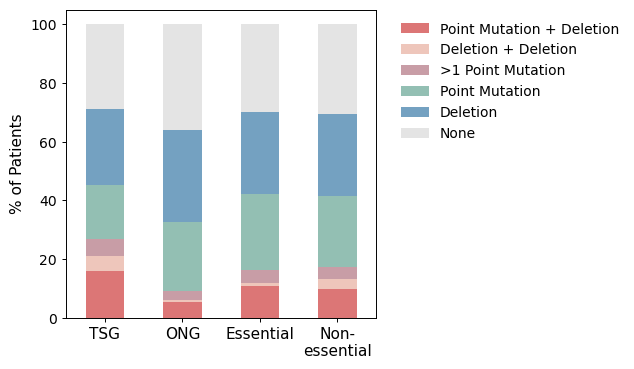

In [9]:
# plt.figure(figsize=(4,4))

config_rcparams()
ax = (catrolesnfprops*100).plot.bar(stacked=True, figsize=(4,4),color=['#DC7676','#EEC6BB','#C89DA6','#93BFB3','#74A1C1','#E4E4E4'])

ax.set_xticklabels(['TSG','ONG','Essential','Non-\nessential'], fontsize=11, rotation=0)
plt.ylabel('% of Patients',fontsize=11)
plt.xlabel(None)

handles, labels = ax.get_legend_handles_labels()
new_labels = ["Point Mutation + Deletion", "Deletion + Deletion",">1 Point Mutation","Point Mutation","Deletion","None"]
ax.legend(handles, new_labels, title=None,fontsize=10, bbox_to_anchor=(1.04, 1),frameon=False)

plt.show()

---

# Fig S1A

In [10]:
tmp1 = pd.merge(tcgamut,roles)
tmp1 = tmp1[tmp1.role=='TSG'].groupby(['Hugo_Symbol','cat'])['tissue'].nunique().reset_index()
tmp2 = pd.merge(tcgawt,roles)
tmp2 = tmp2[tmp2.role=='TSG'].groupby(['Hugo_Symbol','cat'])['tissue'].nunique().reset_index()
cattsgsnf = pd.concat([tmp1,tmp2])
cattsgsnf = cattsgsnf.pivot(index='Hugo_Symbol', columns='cat', values='tissue')
cattsgsnf = cattsgsnf[['mut+del','del+del']]#,'mut+mut','mut','del','WT']]
cattsgsnfprops = cattsgsnf.div(cattsgsnf.sum(axis=1), axis=0)
cattsgsnfprops = cattsgsnfprops.sort_values(by='mut+del',ascending=False)

Text(0.075, 0.55, '                          Patients with biallelic alterations\n\nPrevalence of allelic configurations (%)              Total count                      ')

findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'sans-serif' not found because none of the following families were found: arial


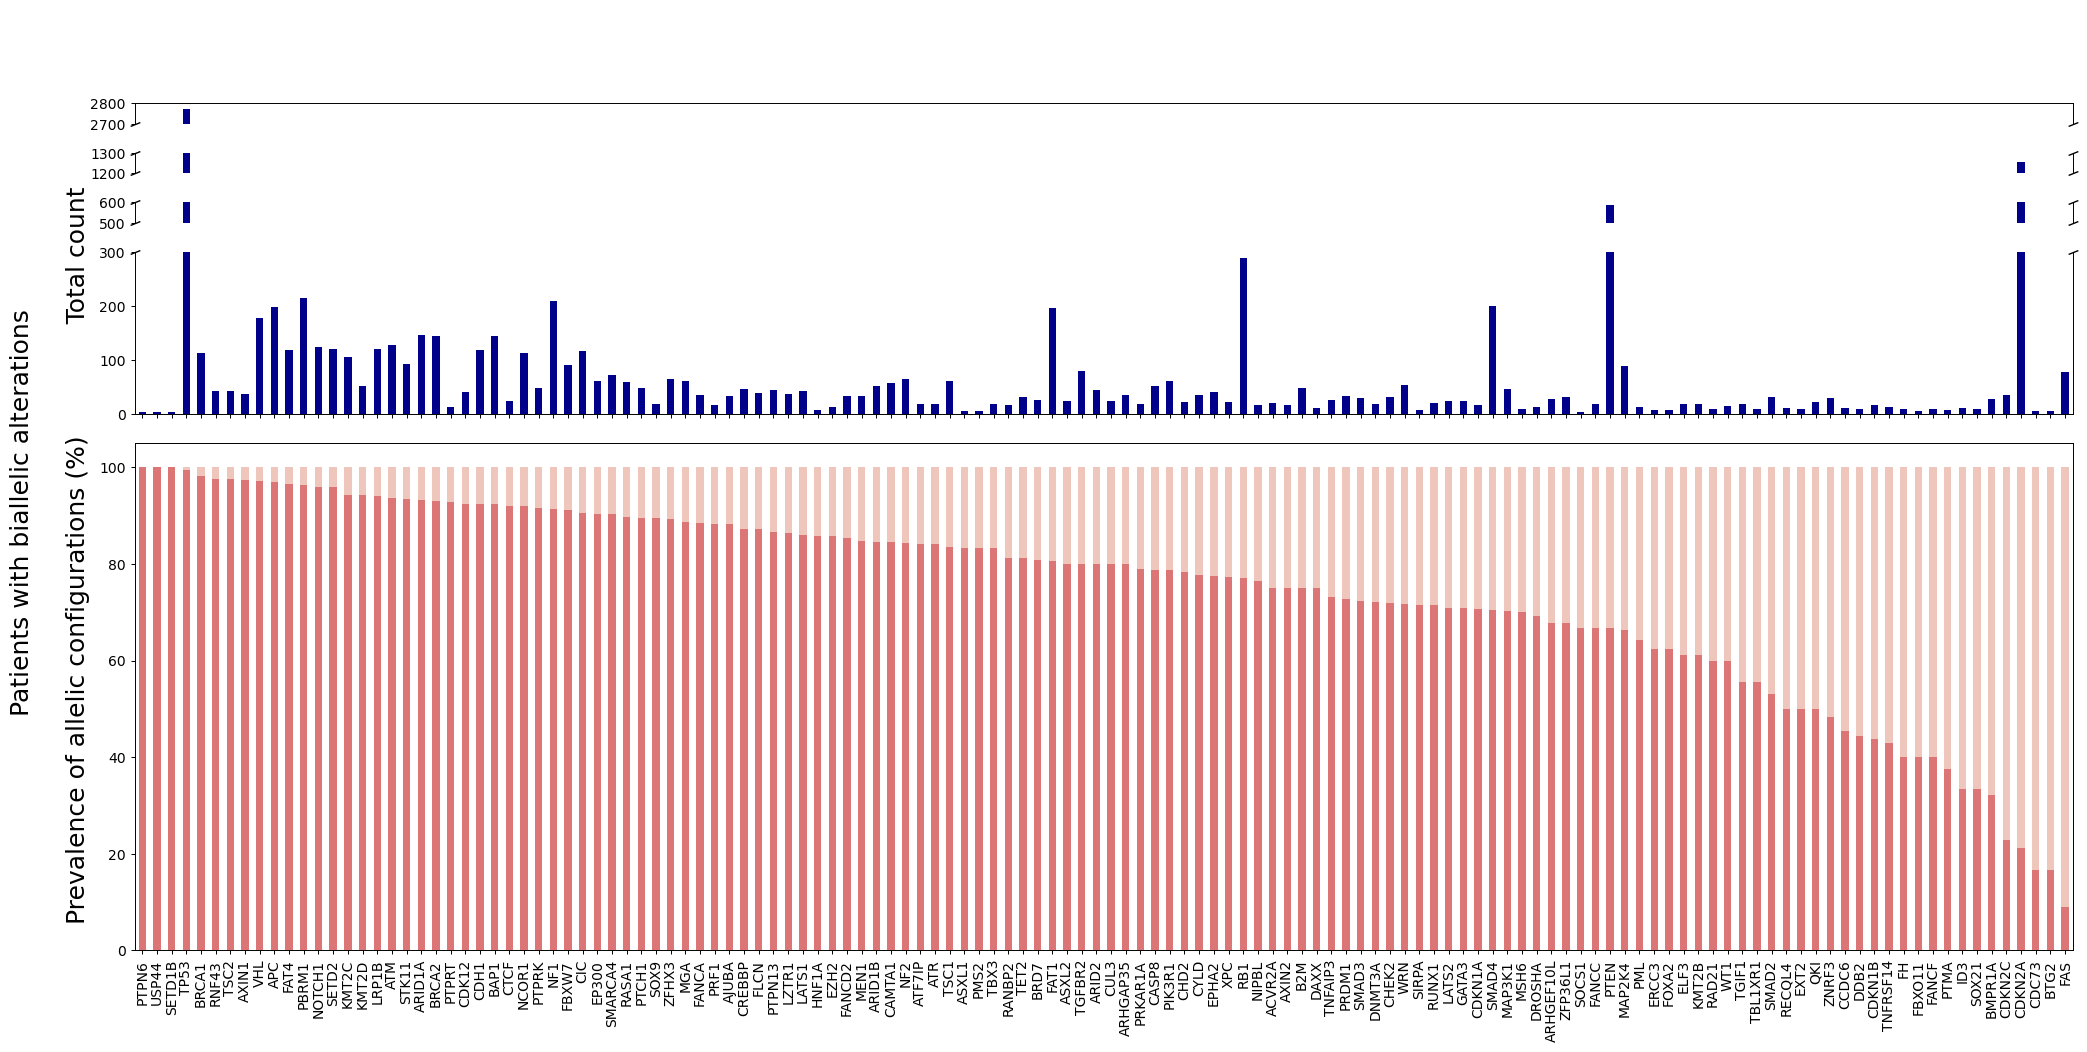

In [11]:
config_rcparams()

fig, (ax1, ax2, ax3, ax4, ax5) = plt.subplots(5, 1, sharex=True, figsize=(25,11), gridspec_kw={'height_ratios': [1, 1, 1, 8,25]})

tmp = cattsgsnfprops.reset_index()[['Hugo_Symbol']].set_index('Hugo_Symbol').join(cattsgsnf.sum(axis=1).to_frame())

tmp.plot(kind='bar', ax=ax1, color='darkblue', legend=False)
tmp.plot(kind='bar', ax=ax2, color='darkblue', legend=False)
tmp.plot(kind='bar', ax=ax3, color='darkblue', legend=False)
tmp.plot(kind='bar', ax=ax4, color='darkblue', legend=False)

(cattsgsnfprops*100).plot(kind='bar', stacked=True, ax=ax5, color=['#DC7676','#EEC6BB'], legend=False)#,'#C89DA6','#93BFB3','#74A1C1','#E4E4E4'])

ax1.set_ylim(2700,2800)
ax2.set_ylim(1200, 1300)
ax3.set_ylim(500, 600) 
ax4.set_ylim(0, 300) 

for ax in [ax1, ax2, ax3]:
    ax.spines['bottom'].set_visible(False)
    ax.tick_params(bottom=False)
for ax in [ax2, ax3, ax4]:
    ax.spines['top'].set_visible(False)
    ax.tick_params(top=False)
    
kwargs = dict(marker=[(-1, -0.4), (1, 0.4)], markersize=7,
              linestyle='none', color='k', clip_on=False)

ax1.plot([0, 1], [0, 0], transform=ax1.transAxes, **kwargs)
ax2.plot([0, 1], [1, 1], transform=ax2.transAxes, **kwargs)

ax2.plot([0, 1], [0, 0], transform=ax2.transAxes, **kwargs)
ax3.plot([0, 1], [1, 1], transform=ax3.transAxes, **kwargs)

ax3.plot([0, 1], [0, 0], transform=ax3.transAxes, **kwargs)
ax4.plot([0, 1], [1, 1], transform=ax4.transAxes, **kwargs)

handles, labels = ax5.get_legend_handles_labels()
new_labels = ["Point Mutation + Deletion", "Deletion + Deletion"]

plt.xlabel(None)
         
fig.text(0.075, 0.55, '                          Patients with biallelic alterations\n\nPrevalence of allelic configurations (%)              Total count                      ', va='center', rotation='vertical', fontsize=18)